In [2]:
import math
import os
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import sumolib
import contextily as cx
import geopandas 
import lib.dataGenLib as dataGenLib
import json
import rtree

In [3]:
%load_ext autoreload
%autoreload 2

In [7]:
dataset_site10_path = './dataset10/rawdata/'

In [8]:
csv_files = dataGenLib.retrieve_csv_files(dataset_site10_path)
csv_files

['tracking_list1607216068.csv',
 'tracking_list1607223548.csv',
 'tracking_list1607230744.csv',
 'tracking_list1607238665.csv',
 'tracking_list1607245551.csv',
 'tracking_list1607252098.csv',
 'tracking_list1607260383.csv',
 'tracking_list1607266197.csv',
 'tracking_list1607271205.csv',
 'tracking_list1607277017.csv',
 'tracking_list1607283994.csv']

In [9]:
# res = []
# for f in csv_files[:]:
#     df = pd.read_all_csv(dataset_site10_path+f,delimiter=";")
#     print(df.shape)
#     res.append(df)
df = dataGenLib.read_all_csv(csv_files,dataset_site10_path)
df.head(2)


,Id,timestamp,positionX,positionY,positionZ,sizeX,sizeY,sizeZ,VelX,VelY,VelZ,Vel,Class
0,7178720,1607216068984,-79.763962,-36.845356,-0.440630,5.672656,0.155018,0.160686,0.003065,-0.036308,-0.000708,0.131200,UNKNOWN
1,7192515,1607216068984,66.896500,75.287140,-0.046115,1.481961,0.730370,11.103112,0.017355,0.106299,0.186418,0.775066,UNKNOWN


In [10]:
df['timestamp'].astype('datetime64[ms]').max(),df['timestamp'].astype('datetime64[ms]').min()

(Timestamp('2020-12-06 21:47:33.270000'),
 Timestamp('2020-12-06 00:54:28.984000'))

In [11]:
# df1 = df.groupby(['Id'],group_keys=True,dropna=False)
# vehicle_list = []
# for key,val in df1:
#     df2 = val.value_counts(['Id','Class'],normalize=True)
#     if "VEHICLE" in df2.index.levels[1]:
#         if df2[:,"VEHICLE"].values>0.5:
#             vehicle_list.append(key[0])
            
vehicle_list = dataGenLib.filtrate_object(df)

In [304]:
df_v = dataGenLib.select_by_id(df,vehicle_list)

In [13]:
# df_v[df_v["Vel"]>100]

In [ ]:
# df_v = [df[df['Id']==i] for i in vehicle_list]
# df_v = pd.concat(df_v)

# v_len = []
# for k,v in df_v.groupby('Id'):
#     # print(v)
#     # There are some duplications, duplicated Id at the same time.
#     new_v = v.drop_duplicates(['Id','timestamp']).copy()
#     # print(v['timestamp'].min())
#     new_v['ts'] = np.ceil((v['timestamp'] - new_v['timestamp'].min())/100)
#     v_len.append(len(new_v))
v_list, low_list, up_list = dataGenLib.pad_data(df_v, 50.,100.)
# max(v_len), min(v_len)
l_v_df = dataGenLib.select_by_id(df_v,v_list)
l_low_df = dataGenLib.select_by_id(df_v,low_list)
l_up_df = dataGenLib.select_by_id(df_v,up_list)
# l_v_df, l_low_df, l_up_df
    

In [ ]:
x = pd.DataFrame().reindex_like(df_v[:10]).reset_index(drop=True)
x = x.reindex(range(10))
xx = df_v[:4].copy()
xx.reindex(range(10),method='pad')

,Id,timestamp,positionX,positionY,positionZ,sizeX,sizeY,sizeZ,VelX,VelY,VelZ,Vel,Class
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,7219084.0,1.0,-95.295219,30.947761,0.105266,14.202774,0.573912,5.998596,0.601073,-0.939662,-0.038813,4.018089,VEHICLE
5,7219084.0,1.0,-95.295219,30.947761,0.105266,14.202774,0.573912,5.998596,0.601073,-0.939662,-0.038813,4.018089,VEHICLE
6,7219084.0,1.0,-95.295219,30.947761,0.105266,14.202774,0.573912,5.998596,0.601073,-0.939662,-0.038813,4.018089,VEHICLE
7,7219084.0,1.0,-95.295219,30.947761,0.105266,14.202774,0.573912,5.998596,0.601073,-0.939662,-0.038813,4.018089,VEHICLE
8,7219084.0,1.0,-95.295219,30.947761,0.105266,14.202774,0.573912,5.998596,0.601073,-0.939662,-0.038813,4.018089,VEHICLE
9,7219084.0,1.0,-95.295219,30.947761,0.105266,14.202774,0.573912,5.998596,0.601073,-0.939662,-0.038813,4.018089,VEHICLE


In [32]:
# counts, bins = np.histogram(np.sort(v_len),bins=np.arange(0,max(v_len),10))
# plt.figure(figsize=(12,4))
# plt.subplot(121)
# plt.hist(v_len,bins=bins)
# plt.xlim((0,600))
# plt.subplot(122)
# y = counts.cumsum()/counts.cumsum().max()
# plt.plot(bins[:-1],y)
# plt.xlim((0,600))
# plt.show()

In [33]:
# v_len = np.array(np.sort(v_len))
# y = (v_len - v_len.min()) / (v_len.max() - v_len.min())
# y

In [34]:
# f = plt.figure()
# plt.bar(range(len(y)),y)
# max_y = y.cumsum()[-1]
# plt.plot(range(len(y)),y.cumsum()/max_y)
# plt.show()

In [45]:
net = sumolib.net.readNet("./dataset10/map/site10_new.net.xml")

In [46]:
p = net.getGeoProj()
p.crs 

<Projected CRS: +proj=utm +zone=31 +ellps=WGS84 +datum=WGS84 +unit ...>
Name: unknown
Axis Info [cartesian]:
- E[east]: Easting (metre)
- N[north]: Northing (metre)
Area of Use:
- undefined
Coordinate Operation:
- name: UTM zone 31N
- method: Transverse Mercator
Datum: World Geodetic System 1984
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [47]:
# with open("rsu10.json","r") as f:
#     rsu_info = json.load(f)
# lat = rsu_info["geographicalPosition"]["latitude"]
# lon = rsu_info["geographicalPosition"]["longitude"]
# head =  rsu_info["trueHeading"]
lat,lon,head = dataGenLib.rsu_info("rsu10.json")
head

-124

In [128]:
# x, y = net.convertLonLat2XY(lon,lat)
x, y = p(lon,lat)
x, y

(359351.5793442117, 5472384.743682341)

In [49]:
theta = math.radians(head)
rotation = np.matrix([[np.sin(theta),np.cos(theta)],
                      [np.cos(theta),-np.sin(theta)]])
rotation

matrix([[-0.82903757, -0.5591929 ],
        [-0.5591929 ,  0.82903757]])

In [50]:
l_v_df.loc[:,['positionX','positionY']]

,positionX,positionY
81024,19.540550,42.424248
81032,19.466246,41.955353
81041,18.996057,41.162708
81050,18.852346,40.170715
81055,17.984152,37.436756
...,...,...
391639,-96.001700,32.243664
391646,-95.983711,32.211277
391651,-95.815476,34.413284
391656,-96.098442,36.379883


In [197]:
l_v_df

,Id,timestamp,positionX,positionY,positionZ,sizeX,sizeY,sizeZ,VelX,VelY,VelZ,Vel,Class
81024,7221999,1607217271477,19.540550,42.424248,-5.209050,0.336518,1.756009,0.054197,0.000000,0.000000,0.000000,0.000000,UNKNOWN
81032,7221999,1607217271546,19.466246,41.955353,-5.160212,0.338746,1.732674,0.054571,-0.380886,-2.403544,0.251149,8.807262,UNKNOWN
81041,7221999,1607217271625,18.996057,41.162708,-5.065175,0.359182,1.584916,0.051824,-2.750076,-5.646921,0.657257,22.734968,VEHICLE
81050,7221999,1607217271713,18.852346,40.170715,-4.958996,0.365822,1.586774,0.052321,-2.406437,-7.371049,0.827365,28.072576,VEHICLE
81055,7221999,1607217272022,17.984152,37.436756,-4.631666,0.364540,1.580315,0.052138,-2.724034,-8.513982,1.007518,32.384664,VEHICLE
...,...,...,...,...,...,...,...,...,...,...,...,...,...
391639,7372191,1607291066943,-96.001700,32.243664,0.163620,12.715835,0.490921,5.926392,0.730016,-1.057611,-0.030449,4.627633,VEHICLE
391646,7372191,1607291066947,-95.983711,32.211277,0.159113,12.883312,0.496938,5.935308,0.702588,-0.968476,-0.037911,4.309508,VEHICLE
391651,7372191,1607291067494,-95.815476,34.413284,0.528249,12.788837,0.493177,5.875956,-1.000489,5.600269,0.483185,20.553908,VEHICLE
391656,7372191,1607291067494,-96.098442,36.379883,0.932398,12.697825,0.489819,5.817196,-1.068502,7.881047,1.012243,28.862311,VEHICLE


In [199]:
# rot_v_df = l_v_df.loc[:,['positionX','positionY']].dot(rotation)
rot_v_df = dataGenLib.rot_data(l_v_df,head)
rot_low_df = rotation.dot(np.array([l_low_df.loc[:,'positionX'],l_low_df.loc[:,'positionY']]))
rot_up_df = rotation.dot(np.array([l_up_df.loc[:,'positionX'],l_up_df.loc[:,'positionY']]))
v_rx = rot_v_df.loc[:,"rot_x"]+x
v_ry = rot_v_df.loc[:,"rot_y"]+y

low_rx = np.array(rot_low_df[0,:]).flatten()+x
low_ry = np.array(rot_low_df[1,:]).flatten()+y

up_rx = np.array(rot_up_df[0,:]).flatten()+x
up_ry = np.array(rot_up_df[1,:]).flatten()+y

In [200]:
rot_v_df

,Id,timestamp,positionX,positionY,positionZ,sizeX,sizeY,sizeZ,VelX,VelY,VelZ,Vel,Class,rot_x,rot_y
81024,7221999,1607217271477,19.540550,42.424248,-5.209050,0.336518,1.756009,0.054197,0.000000,0.000000,0.000000,0.000000,UNKNOWN,-39.923189,24.244358
81032,7221999,1607217271546,19.466246,41.955353,-5.160212,0.338746,1.732674,0.054571,-0.380886,-2.403544,0.251149,8.807262,UNKNOWN,-39.599385,23.897177
81041,7221999,1607217271625,18.996057,41.162708,-5.065175,0.359182,1.584916,0.051824,-2.750076,-5.646921,0.657257,22.734968,VEHICLE,-38.766340,23.502971
81050,7221999,1607217271713,18.852346,40.170715,-4.958996,0.365822,1.586774,0.052321,-2.406437,-7.371049,0.827365,28.072576,VEHICLE,-38.092482,22.760934
81055,7221999,1607217272022,17.984152,37.436756,-4.631666,0.364540,1.580315,0.052138,-2.724034,-8.513982,1.007518,32.384664,VEHICLE,-35.843906,20.979867
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
391639,7372191,1607291066943,-96.001700,32.243664,0.163620,12.715835,0.490921,5.926392,0.730016,-1.057611,-0.030449,4.627633,VEHICLE,61.558588,80.414678
391646,7372191,1607291066947,-95.983711,32.211277,0.159113,12.883312,0.496938,5.935308,0.702588,-0.968476,-0.037911,4.309508,VEHICLE,61.561785,80.377769
391651,7372191,1607291067494,-95.815476,34.413284,0.528249,12.788837,0.493177,5.875956,-1.000489,5.600269,0.483185,20.553908,VEHICLE,60.190965,82.109240
391656,7372191,1607291067494,-96.098442,36.379883,0.932398,12.697825,0.489819,5.817196,-1.068502,7.881047,1.012243,28.862311,VEHICLE,59.325847,83.897857


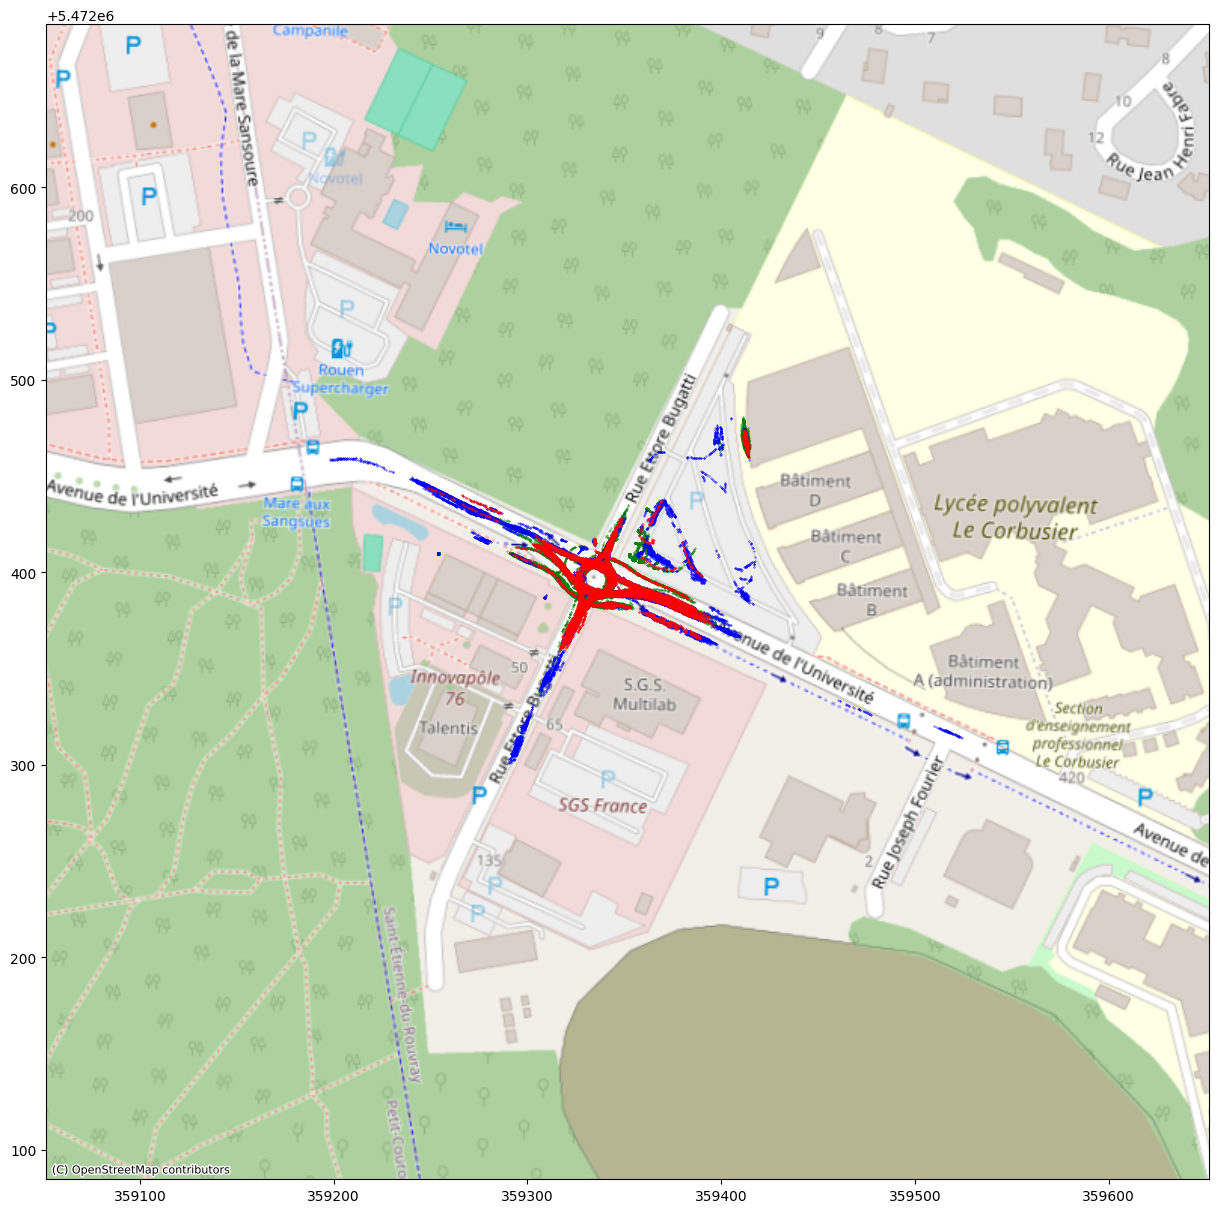

In [42]:
fig,ax = plt.subplots(figsize=(15,15))
ax.scatter(up_rx,up_ry,s=0.1,c='g')
ax.scatter(low_rx,low_ry,s=0.1,c='b')
ax.scatter(v_rx,v_ry,s=0.1,c='r')
ax.set_xlim([x-300,x+300])
ax.set_ylim([y-300,y+300])

cx.add_basemap(
    ax,
    crs= p.crs,
    source=cx.providers.OpenStreetMap.Mapnik
)

In [43]:
l_low_df['Vel'], l_v_df["Vel"],l_up_df["Vel"]

(13001     25.528415
 13009     32.209644
 13017     64.823302
 36292     35.718394
 36300     55.998964
             ...    
 396629    15.501859
 396642    37.662654
 396648    53.276600
 396654    59.782199
 396660    54.904416
 Name: Vel, Length: 77306, dtype: float64,
 81024      0.000000
 81032      8.807262
 81041     22.734968
 81050     28.072576
 81055     32.384664
             ...    
 391639     4.627633
 391646     4.309508
 391651    20.553908
 391656    28.862311
 391663    35.313747
 Name: Vel, Length: 65249, dtype: float64,
 4         4.018089
 10        4.900553
 16        4.655026
 23        4.800962
 28        4.738079
             ...   
 403685    4.243632
 403692    2.812790
 403699    2.428845
 403705    3.540738
 403711    1.943657
 Name: Vel, Length: 717301, dtype: float64)

In [ ]:
l_up_df["timestamp"].astype('datetime64[ms]')

4        2020-12-06 00:54:28.984
10       2020-12-06 00:54:28.984
16       2020-12-06 00:54:29.041
23       2020-12-06 00:54:29.111
28       2020-12-06 00:54:29.111
                   ...          
403685   2020-12-06 21:47:32.726
403692   2020-12-06 21:47:32.809
403699   2020-12-06 21:47:32.809
403705   2020-12-06 21:47:32.899
403711   2020-12-06 21:47:33.270
Name: timestamp, Length: 717301, dtype: datetime64[ms]

In [229]:
x, y = net.convertLonLat2XY(lon,lat)
rot_v_df = dataGenLib.rot_data(l_v_df,head)
rot_low_df = dataGenLib.rot_data(l_low_df,head)
rot_up_df = dataGenLib.rot_data(l_up_df,head)

v_rx = rot_v_df.loc[:,'rot_x']+x
v_ry = rot_v_df.loc[:,'rot_y']+y
# radius = 0.5
# edges = net.getNeighboringEdges(v_rx.iloc[0], v_ry.iloc[0], radius)
# # pick the closest edge
# if len(edges) > 0:
#     distancesAndEdges = sorted([(dist, edge) for edge, dist in edges], key=lambda x:x[0])
#     dist, closestEdge = distancesAndEdges[0]
    
# edges,dist,closestEdge.getID() , net.getEdge('60546306#1').getType()
row,_ = rot_v_df.shape
edge_list = []
for i in range(row):
   dist, edge = dataGenLib.on_road(v_rx.iloc[i],v_ry.iloc[i],net,1.5)
   if edge is not None:
      # print(edge)
      edge_list.append(edge.getID())
   else:
      edge_list.append(edge)
rot_v_df['edge'] = edge_list


v_rx = rot_low_df.loc[:,'rot_x']+x
v_ry = rot_low_df.loc[:,'rot_y']+y
row,_ = rot_low_df.shape
edge_list = []
for i in range(row):
   dist, edge = dataGenLib.on_road(v_rx.iloc[i],v_ry.iloc[i],net,1.5)
   if edge is not None:
      # print(edge)
      edge_list.append(edge.getID())
   else:
      edge_list.append(edge)
rot_low_df['edge'] = edge_list


v_rx = rot_up_df.loc[:,'rot_x']+x
v_ry = rot_up_df.loc[:,'rot_y']+y
row,_ = rot_up_df.shape
edge_list = []
for i in range(row):
   dist, edge = dataGenLib.on_road(v_rx.iloc[i],v_ry.iloc[i],net,1.5)
   if edge is not None:
      # print(edge)
      edge_list.append(edge.getID())
   else:
      edge_list.append(edge)
rot_up_df['edge'] = edge_list


In [230]:
rot_v_df = rot_v_df[rot_v_df['edge'].notnull()]
rot_low_df = rot_low_df[rot_low_df['edge'].notnull()]
rot_up_df = rot_up_df[rot_up_df['edge'].notnull()]

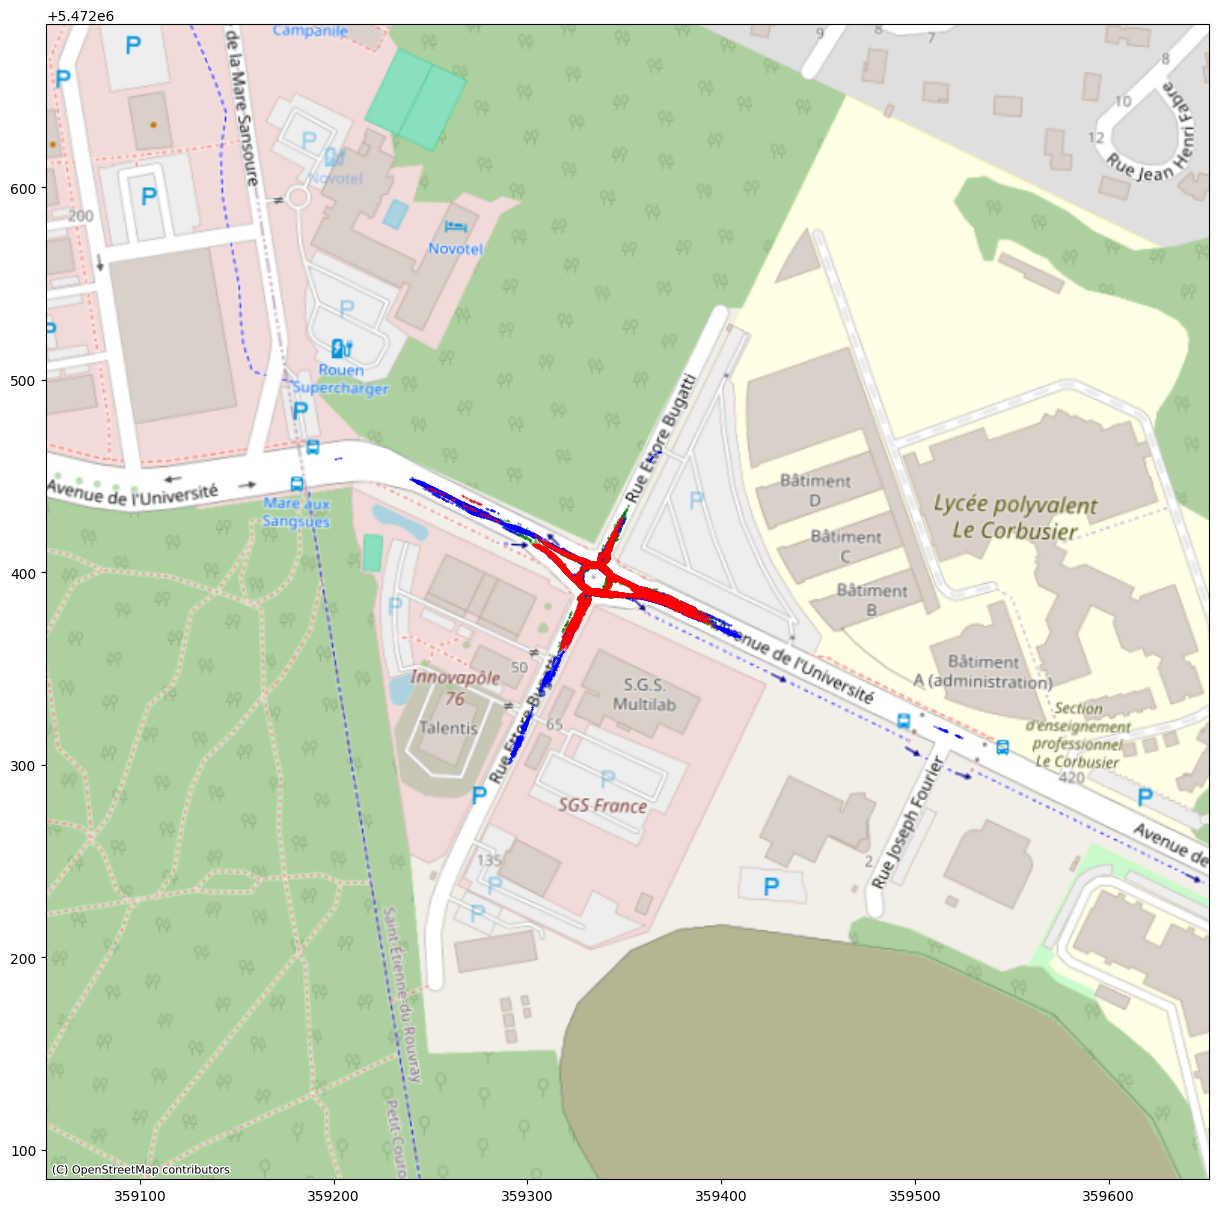

In [231]:
x, y = p(lon,lat)
v_rx = rot_v_df.loc[:,"rot_x"]+x
v_ry = rot_v_df.loc[:,"rot_y"]+y

low_rx = rot_low_df.loc[:,"rot_x"]+x
low_ry = rot_low_df.loc[:,"rot_y"]+y

up_rx = rot_up_df.loc[:,"rot_x"]+x
up_ry = rot_up_df.loc[:,"rot_y"]+y

fig,ax = plt.subplots(figsize=(15,15))
ax.scatter(up_rx,up_ry,s=0.1,c='g')
ax.scatter(low_rx,low_ry,s=0.1,c='b')
ax.scatter(v_rx,v_ry,s=0.1,c='r')
ax.set_xlim([x-300,x+300])
ax.set_ylim([y-300,y+300])

cx.add_basemap(
    ax,
    crs= p.crs,
    source=cx.providers.OpenStreetMap.Mapnik
)

In [232]:
rot_v_df

,Id,timestamp,positionX,positionY,positionZ,sizeX,sizeY,sizeZ,VelX,VelY,VelZ,Vel,Class,rot_x,rot_y,edge
81024,7221999,1607217271477,19.540550,42.424248,-5.209050,0.336518,1.756009,0.054197,0.000000,0.000000,0.000000,0.000000,UNKNOWN,-39.923189,24.244358,60546306#1
81032,7221999,1607217271546,19.466246,41.955353,-5.160212,0.338746,1.732674,0.054571,-0.380886,-2.403544,0.251149,8.807262,UNKNOWN,-39.599385,23.897177,60546306#1
81041,7221999,1607217271625,18.996057,41.162708,-5.065175,0.359182,1.584916,0.051824,-2.750076,-5.646921,0.657257,22.734968,VEHICLE,-38.766340,23.502971,60546306#1
81050,7221999,1607217271713,18.852346,40.170715,-4.958996,0.365822,1.586774,0.052321,-2.406437,-7.371049,0.827365,28.072576,VEHICLE,-38.092482,22.760934,60546306#1
81055,7221999,1607217272022,17.984152,37.436756,-4.631666,0.364540,1.580315,0.052138,-2.724034,-8.513982,1.007518,32.384664,VEHICLE,-35.843906,20.979867,60546306#1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
363538,7371520,1607290594326,8.548418,12.147860,-4.413105,4.454805,1.716641,1.232607,-5.601542,-6.246482,0.017370,30.204862,VEHICLE,-13.879957,5.290817,60546290#0
363545,7371520,1607290594435,7.774260,11.508366,-4.345346,4.434392,1.823731,1.227391,-5.965414,-6.002667,0.136004,30.469842,VEHICLE,-12.880550,5.193556,60546290#0
363552,7371520,1607290594546,7.218145,11.013812,-4.261747,4.409860,1.830580,1.223751,-5.868398,-5.497845,0.257084,28.963894,VEHICLE,-12.142959,5.094528,60546290#0
363558,7371520,1607290594551,7.162687,11.049804,-4.160365,4.401549,1.830307,1.223004,-5.915356,-5.384368,0.425610,28.836875,VEHICLE,-12.117109,5.155379,60546290#0


In [ ]:
rot_v_df


,Id,timestamp,positionX,positionY,positionZ,sizeX,sizeY,sizeZ,VelX,VelY,VelZ,Vel,Class,rot_x,rot_y,edge
81024,7221999,1607217271477,19.540550,42.424248,-5.209050,0.336518,1.756009,0.054197,0.000000,0.000000,0.000000,0.000000,UNKNOWN,-39.923189,24.244358,60546306#1
81032,7221999,1607217271546,19.466246,41.955353,-5.160212,0.338746,1.732674,0.054571,-0.380886,-2.403544,0.251149,8.807262,UNKNOWN,-39.599385,23.897177,60546306#1
81041,7221999,1607217271625,18.996057,41.162708,-5.065175,0.359182,1.584916,0.051824,-2.750076,-5.646921,0.657257,22.734968,VEHICLE,-38.766340,23.502971,60546306#1
81050,7221999,1607217271713,18.852346,40.170715,-4.958996,0.365822,1.586774,0.052321,-2.406437,-7.371049,0.827365,28.072576,VEHICLE,-38.092482,22.760934,60546306#1
81055,7221999,1607217272022,17.984152,37.436756,-4.631666,0.364540,1.580315,0.052138,-2.724034,-8.513982,1.007518,32.384664,VEHICLE,-35.843906,20.979867,60546306#1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
363538,7371520,1607290594326,8.548418,12.147860,-4.413105,4.454805,1.716641,1.232607,-5.601542,-6.246482,0.017370,30.204862,VEHICLE,-13.879957,5.290817,60546290#0
363545,7371520,1607290594435,7.774260,11.508366,-4.345346,4.434392,1.823731,1.227391,-5.965414,-6.002667,0.136004,30.469842,VEHICLE,-12.880550,5.193556,60546290#0
363552,7371520,1607290594546,7.218145,11.013812,-4.261747,4.409860,1.830580,1.223751,-5.868398,-5.497845,0.257084,28.963894,VEHICLE,-12.142959,5.094528,60546290#0
363558,7371520,1607290594551,7.162687,11.049804,-4.160365,4.401549,1.830307,1.223004,-5.915356,-5.384368,0.425610,28.836875,VEHICLE,-12.117109,5.155379,60546290#0


In [413]:
ll = dataGenLib.data_padding(rot_v_df,pad_method='linear')

In [414]:
ll[90:120]

,Id,timestamp,positionX,positionY,positionZ,sizeX,sizeY,sizeZ,VelX,VelY,VelZ,Vel,Class,rot_x,rot_y,edge,ts
90,7221999.0,1.607217e+12,-22.149021,-20.723629,-3.686893,3.571006,1.690951,1.163019,-4.856483,-8.489030,0.009537,35.208138,VEHICLE,29.950877,-4.795092,-172341587#1,90.000000
91,7221999.0,1.607217e+12,-22.999008,-21.900562,-3.756638,3.538568,1.690503,1.151864,-5.266839,-9.004931,-0.074858,37.556471,VEHICLE,31.313681,-5.295507,-172341587#1,91.000000
92,7221999.0,1.607217e+12,-23.631241,-23.075235,-3.821174,3.505374,1.690998,1.140879,-5.336805,-9.446535,-0.145597,39.062855,VEHICLE,32.494694,-5.915815,-172341587#1,92.000000
93,7221999.0,1.607217e+12,-24.077080,-24.115124,-4.012700,3.496222,1.690657,1.131225,-5.150225,-9.686784,-0.352370,39.515271,VEHICLE,33.445810,-6.528611,-172341587#1,93.000000
94,7221999.0,1.607217e+12,-24.673397,-25.210789,-4.087619,3.486795,1.688495,1.122243,-5.140566,-9.935275,-0.412987,40.298406,VEHICLE,34.552867,-7.103503,-172341587#1,94.000000
95,7221999.0,1.607217e+12,-25.204470,-26.177740,-4.129988,3.453723,1.687412,1.111366,-5.090631,-9.975508,-0.424631,40.346603,VEHICLE,35.533859,-7.608170,-172341587#1,95.000000
96,7221999.0,1.607217e+12,-25.744005,-27.144630,-4.173660,3.420982,1.686339,1.100598,-5.054444,-9.978451,-0.435435,40.298537,VEHICLE,36.521832,-8.108053,-172341587#1,96.000000
97,7221999.0,1.607217e+12,-24.870084,-25.730716,-4.188953,3.420982,1.686339,1.100598,-5.012043,-9.861303,-0.410921,39.863349,VEHICLE,35.006668,-7.424556,-172341587#1,94.222222
98,7221999.0,1.607217e+12,-23.996163,-24.316802,-4.204245,3.420982,1.686339,1.100598,-4.969642,-9.744155,-0.386407,39.428162,VEHICLE,33.491504,-6.741058,-172341587#1,92.444444
99,7221999.0,1.607217e+12,-23.122242,-22.902887,-4.219538,3.420982,1.686339,1.100598,-4.927241,-9.627007,-0.361893,38.992975,VEHICLE,31.976339,-6.057560,-172341587#1,90.666667


In [415]:
from datetime import datetime
now = datetime.now()
time = now.strftime("%Y%d%m_%H:%M:%S")
ll.to_csv('./dataset10/training/traning_'+time+'.csv',index=False)

In [4]:
ddf = pd.DataFrame([('V', np.nan, -1.0, 1.0),
                   (np.nan, 2.0, np.nan, np.nan),                 
                   ('U', 3.0, np.nan, 9.0),
                    ('V', np.nan, 3.0, np.nan)],
   columns=list('abcd'))

ddf[['c']] = ddf[['c']].interpolate(method='linear', limit_direction='forward', axis=0)
ddf = ddf.ffill()
ddf


,a,b,c,d
0,V,NaN,-1.000000,1.0
1,V,2.0,0.333333,1.0
2,U,3.0,1.666667,9.0
3,V,3.0,3.000000,9.0


In [ ]:
ddf = pd.DataFrame([(np.nan, np.nan, np.nan,np.nan),
                   (np.nan, np.nan, np.nan, np.nan),                 
                   (np.nan, np.nan, np.nan, np.nan),
                    (np.nan, np.nan, np.nan, np.nan)],
   columns=list('abcd'))
q = []
ddf1 = ddf.copy()
ddf = ddf.dropna()

,a,b,c,d
0,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN
